In [1]:
import numpy as np
import pandas as pd
import random
from sklearn.linear_model import LogisticRegression
import sys

sys.path.insert(0, "../../../../Modules")

pd.set_option('display.max_columns', None)
random.seed(0)
np.random.seed(0)

from utils import *

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
NUTS0 = 'GR'
NUTS2 = 'CMacedonia'

In [4]:
r_u = 0.05
near_u = 0.25
smote = 1
scaler = 'minmax'
#years_to_remove = [year for year in range(2012, 2018)]
years_to_remove = []
path = f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_Q1_2011_2022.csv'

In [5]:
dataset = read_data(path, exclude_years = years_to_remove)
dataset.head()

,year,nuts3,nuts2,x,y,min_temp_q1,mean_temp_q1,max_temp_q1,prec_q1,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,ndvi_q1,ndwi_q1,ndmi_q1,ndbi_q1,ndvi_mean_q1,ndwi_mean_q1,ndmi_mean_q1,ndbi_mean_q1,ndvi_std_q1,ndwi_std_q1,ndmi_std_q1,ndbi_std_q1,M_TOTAL,M_Y_LT_15,M_Y15-64,M_Y_GE65,F_TOTAL,F_Y_LT_15,F_Y15-64,F_Y_GE65,MIO_EUR,L_TOTAL,UNL_TOTAL,culex_pipiens,WNV_cases
0,2011,ημαθιας,κεντρικης μακεδονιας,22.215876,40.552658,3.154111,6.247768,9.383282,7.851225,14.583333,18.666667,49.122807,768.952455,34.0,-4.0,38.0,9.166667,23.833333,23.833333,4.833333,1580.0,347.0,21.0,69.297060,585.0,195.0,195.0,488.0,0.253413,0.164233,0.382909,-0.382909,0.243740,0.189907,0.401026,-0.401026,0.044376,0.051454,0.050562,0.050562,70507.0,11806.0,44835.0,13866.0,72328.0,11360.0,44584.0,16384.0,2016.25,5025.2,5265.4,15432,1
1,2011,θεσσαλονικης,κεντρικης μακεδονιας,23.139532,40.695359,3.805192,6.847387,9.672913,7.258680,16.125000,20.083333,46.705426,865.533204,39.0,-4.0,43.0,10.333333,26.166667,26.500000,5.333333,1341.0,362.0,8.0,88.115950,512.0,157.0,210.0,391.0,0.331371,-0.125325,0.181410,-0.181410,0.328781,-0.127656,0.175605,-0.175605,0.053834,0.060592,0.055271,0.055271,544496.0,87330.0,375115.0,82051.0,593794.0,84172.0,402246.0,107376.0,19627.51,9804.6,10058.8,17986,1
2,2011,κιλκις,κεντρικης μακεδονιας,22.758634,41.016242,3.615530,7.186785,10.130769,4.959644,16.083333,21.500000,46.739130,890.054476,41.0,-5.0,46.0,9.833333,26.166667,27.000000,5.000000,1417.0,379.0,10.0,78.775725,584.0,198.0,223.0,377.0,0.238927,-0.089832,0.144111,-0.144111,0.241070,-0.091286,0.144951,-0.144951,0.023444,0.040297,0.033327,0.033327,40335.0,5963.0,24603.0,9769.0,41005.0,5680.0,23436.0,11889.0,1124.52,5809.2,5920.4,15562,0
3,2011,πελλας,κεντρικης μακεδονιας,22.109199,40.888821,3.344699,6.581308,9.599950,6.495086,14.750000,19.166667,47.916667,790.425662,36.0,-4.0,40.0,9.333333,24.500000,24.500000,4.666667,1630.0,348.0,19.0,63.316479,629.0,219.0,219.0,490.0,0.257757,0.126741,0.363656,-0.363656,0.254301,0.126465,0.361181,-0.361181,0.039384,0.052719,0.050437,0.050437,70390.0,11159.0,44537.0,14694.0,71954.0,11052.0,43212.0,17690.0,1938.34,5025.2,5265.4,13759,1
4,2011,πιεριας,κεντρικης μακεδονιας,22.441443,40.269748,4.506731,6.513187,7.631595,9.737422,15.916667,18.333333,45.833333,769.247960,37.0,-3.0,40.0,15.666667,25.500000,25.500000,6.500000,1470.0,325.0,27.0,70.741701,556.0,174.0,174.0,437.0,0.269825,0.101198,0.347946,-0.347946,0.258944,0.119827,0.353585,-0.353585,0.044928,0.065635,0.063431,0.063431,62665.0,10433.0,40170.0,12062.0,65045.0,10152.0,40273.0,14620.0,1725.03,5025.2,5265.4,18496,0


In [6]:
# #Check months

# dataset = dataset.query('month >= 6 & month <= 10')
# dataset.reset_index(inplace=True, drop=True)

In [7]:
dataset['nuts3'].unique().shape

(7,)

In [8]:
print(f'Number of NUTS3 Units in {NUTS2}: {len(dataset.nuts3.unique())}')

Number of NUTS3 Units in CMacedonia: 7


In [9]:
# dsc = dataframe_describe(dataset, target_column='WNV_cases')
# dsc.head(15)

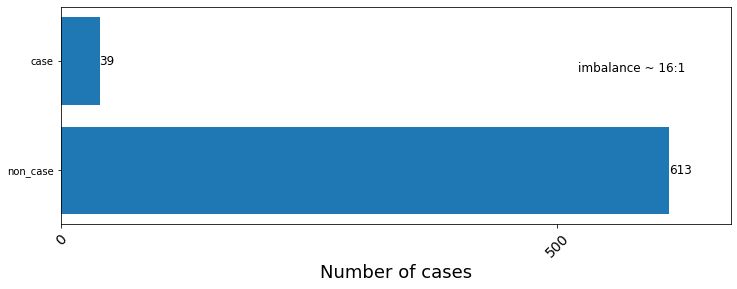

In [10]:
plot_imbalance(dataset, target_column='WNV_cases')

In [11]:
coefficients = []
results_train = pd.DataFrame()
results_test = pd.DataFrame()
feature_names = dataset.select_dtypes(exclude=['object']).drop(columns = ['WNV_cases']).columns

In [12]:
for train_idx, test_idx in yearCV_split(dataset):
    data_train = dataset.iloc[train_idx]
    data_test = dataset.iloc[test_idx]
    
    data_train.reset_index(inplace = True, drop = True)
    data_test.reset_index(inplace = True, drop = True)
    
    X_train = data_train.select_dtypes(exclude=['object']).drop(columns = ['WNV_cases'])
    y_train = data_train['WNV_cases']
    X_test = data_test.select_dtypes(exclude=['object']).drop(columns = ['WNV_cases'])
    y_test = data_test['WNV_cases']
    
    X_train, X_test, y_train, y_test, X_train_df = transform_data(X_train, X_test, y_train, y_test, r_u, near_u, smote, scaler_key=scaler)
    
    w0,w1 = calculate_weights(y_train)

    model = LogisticRegression(max_iter = 1000, class_weight = {0.0: w0, 1.0:w1}, n_jobs = -1, random_state = 0)
    
    train, test, coef = train_and_predict(model, X_train_df, data_test, X_train, y_train, X_test, y_test, spatial_col='nuts3', day_col=None, month_col=None, target_col='WNV_cases')
    
    results_train = results_train.append(train, ignore_index = True)
    results_test = results_test.append(test, ignore_index = True)
    coefficients.append(coef)
    
    print(f"Year: {test['year'].iloc[0]} || w0:{w0}, w1:{w1} || ##")

Year: 2011 || w0:1, w1:21 || ##
Year: 2012 || w0:1, w1:44 || ##
Year: 2013 || w0:1, w1:44 || ##
Year: 2014 || w0:1, w1:26 || ##
Year: 2015 || w0:1, w1:52 || ##
Year: 2016 || w0:1, w1:26 || ##
Year: 2017 || w0:1, w1:52 || ##
Year: 2018 || w0:1, w1:34 || ##
Year: 2019 || w0:1, w1:38 || ##
Year: 2020 || w0:1, w1:35 || ##
Year: 2021 || w0:1, w1:42 || ##
Year: 2022 || w0:1, w1:26 || ##


In [22]:
results_test[results_test['year'] == 2014]

,x,y,nuts3,year,WNV_cases,probability
13,23.139532,40.695359,θεσσαλονικης,2014,0,0.999674
37,22.215876,40.552658,ημαθιας,2014,0,0.995706
48,22.109199,40.888821,πελλας,2014,0,0.992823
49,22.441443,40.269748,πιεριας,2014,0,0.991148
51,23.542098,41.085750,σερρων,2014,0,0.988327
52,23.528794,40.366692,χαλκιδικης,2014,0,0.988148
58,22.758634,41.016242,κιλκις,2014,0,0.981928


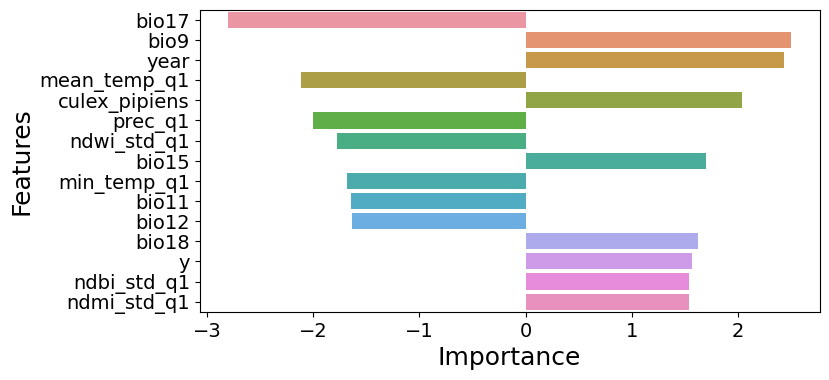

In [14]:
plot_feature_importance(coefficients, feature_names, top = 15, figure_size = (8, 4))

In [15]:
# plot_trend_curve(results_test, list(dsc['case']))

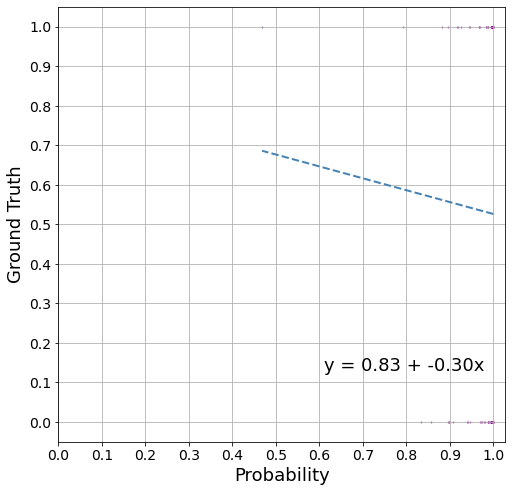

In [16]:
plot_probability_curve(results_test, target_col='WNV_cases')

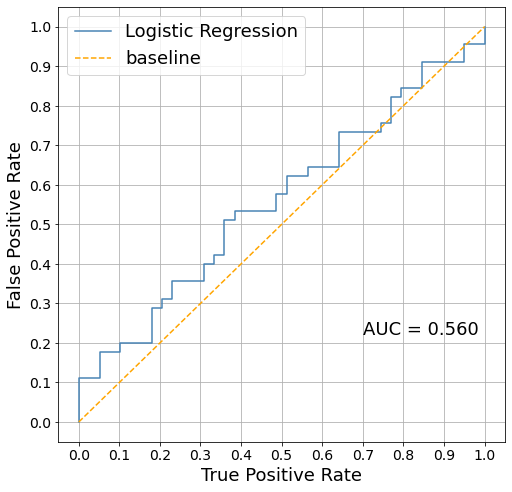

In [17]:
plot_roc_curve(results_test, target_col='WNV_cases')

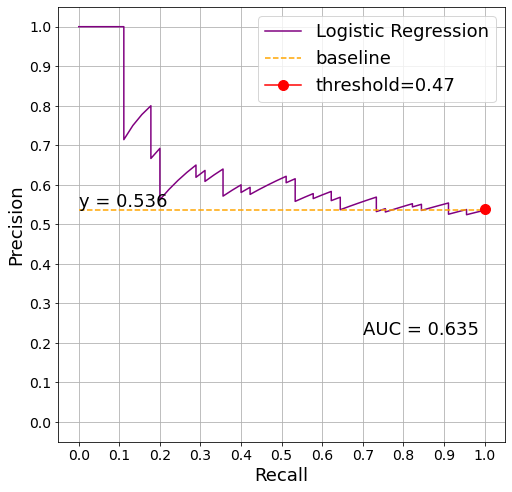

In [18]:
plot_pr_curve(results_test, target_col='WNV_cases', plot_fbeta=True)

In [19]:
operational, cumulative, avg, weighted, r_avg, r_weighted = evaluate_operational(results_test, k = 4, ouput_random = True, sampling_number=100)
print(f'Average: {avg*100:.2f}%\nWeighted Average: {weighted*100:.2f}%')
print(f'\nRandom Average: {r_avg*100:.2f}%\nRandom Weighted Average: {r_weighted*100:.2f}%')

KeyError: 'day'

In [ ]:
operational

,Prediction Date,Infected,Discovered,Random Discovered,Out of,Percentage,percentage,Random Percentage,random percentage
0,01/06/2010,0,0,0.00,0,NaN,NaN,NaN,NaN
1,16/06/2010,0,0,0.00,0,NaN,NaN,NaN,NaN
2,01/07/2010,1,0,0.08,1,0.00 %,0.00,8.00 %,0.0800
3,16/07/2010,12,3,1.28,4,75.00 %,0.75,32.00 %,0.3200
4,01/08/2010,23,4,2.33,4,100.00 %,1.00,58.25 %,0.5825
...,...,...,...,...,...,...,...,...,...
115,16/08/2021,8,2,0.74,4,50.00 %,0.50,18.50 %,0.1850
116,01/09/2021,4,1,0.41,4,25.00 %,0.25,10.25 %,0.1025
117,16/09/2021,1,1,0.11,1,100.00 %,1.00,11.00 %,0.1100
118,01/10/2021,1,0,0.13,1,0.00 %,0.00,13.00 %,0.1300


In [ ]:
cumulative

,Year,Infected,Discovered,Random Discovered,Out Of,Percentage,percentage,Random Percentage,random percentage
0,2010,89,16,9.25,21,76.19 %,0.7619,44.05 %,0.4405
1,2011,24,7,2.50,17,41.18 %,0.4118,14.71 %,0.1471
2,2012,19,3,2.13,19,15.79 %,0.1579,11.21 %,0.1121
3,2013,17,1,1.82,17,5.88 %,0.0588,10.71 %,0.1071
4,2014,0,0,0.00,0,nan %,NaN,nan %,NaN
5,2015,0,0,0.00,0,nan %,NaN,nan %,NaN
6,2016,0,0,0.00,0,nan %,NaN,nan %,NaN
7,2017,0,0,0.00,0,nan %,NaN,nan %,NaN
8,2018,69,9,7.12,29,31.03 %,0.3103,24.55 %,0.2455
9,2019,36,5,3.60,20,25.00 %,0.2500,18.00 %,0.1800


In [ ]:
report_train, report_test = classification_report(results_train, results_test, threshold = 0.1, beta = 4)

In [ ]:
report_test.head(15)

,Year,Infected,Positive Rate,Accuracy,Precision,Recall,F4 Score,Loss
0,2010,89.0,0.2737,0.7908,0.6154,0.7191,0.7120,0.4811
1,2011,24.0,0.6237,0.7008,0.1013,1.0000,0.6570,0.4929
2,2012,19.0,0.6395,0.6620,0.0741,0.9474,0.5594,0.7767
3,2013,17.0,0.5632,0.6979,0.0748,0.9412,0.5597,0.3900
4,2014,0.0,0.6789,0.3211,0.0000,0.0000,0.0000,0.7441
5,2015,0.0,0.7211,0.2789,0.0000,0.0000,0.0000,0.9747
6,2016,0.0,0.6079,0.3921,0.0000,0.0000,0.0000,0.5034
7,2017,0.0,0.5263,0.4737,0.0000,0.0000,0.0000,0.3242
8,2018,69.0,0.7237,0.6511,0.2436,0.9710,0.8260,0.6713
9,2019,36.0,0.4447,0.6993,0.1716,0.8056,0.6617,0.3341


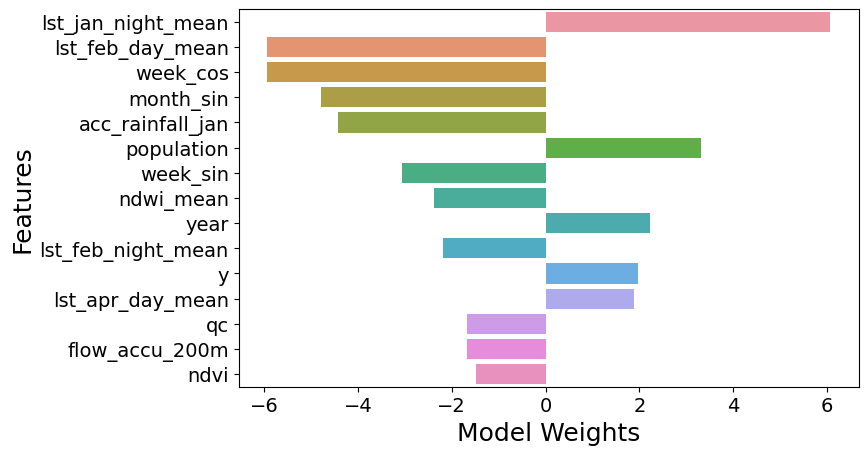

In [ ]:
plot_feature_importance(coefficients, feature_names,  x_label = 'Model Weights', top = 15, figure_size = (8, 5))

In [ ]:
results_test

,x,y,municipality,day,month,year,case,probability
0,22.71688,40.59973,δελτα,16,8,2012,0,0.994850
1,22.71688,40.59973,δελτα,1,9,2012,0,0.994683
2,22.71688,40.59973,δελτα,1,8,2012,0,0.994571
3,22.89198,40.65603,αμπελοκηπων μενεμενης,16,8,2012,0,0.994360
4,22.90326,40.67609,κορδελιου ευοσμου,16,8,2012,0,0.993613
...,...,...,...,...,...,...,...,...
4555,23.98253,40.91510,αμφιπολης,1,6,2012,0,0.000216
4556,23.05120,40.60697,πυλαιας χορτιατη,1,6,2010,0,0.000145
4557,22.95686,40.68150,παυλου μελα,1,6,2010,0,0.000140
4558,23.82811,40.11026,σιθωνιας,16,10,2021,0,0.000133
